In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt
import stim
import pickle
import sinter
from copy import deepcopy
import scipy
from dataclasses import dataclass
from python_tsp.exact import solve_tsp_dynamic_programming
from python_tsp.heuristics import solve_tsp_local_search

import src.device as device
import src.plotting as plotter
import src.stim_dag as stim_dag

from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.TileCode import TileCode
from src.HGPCode import HGPCode
from src.RadialCode import RadialCode
from src.GBCode import GBCode
from src.HypercubeCode import HypercubeCode
from src.decoders import BPOSD

In [29]:
# Making codes
codes = []
code_types = []
code_nkds = []
code_data_coodes = []

ds_surface = [3, 5, 7, 9, 11]
for d in ds_surface:
    code = RotatedSurfaceCode(d)
    codes.append(code)
    code_types.append('Surface')
    code_nkds.append(code.compute_code_parameters())

rs_simplex = [3,4]
for r in rs_simplex:
    code = HGPCode.simplex_code(r)
    codes.append(code)
    code_types.append('Simplex')
    code_nkds.append(code.compute_code_parameters())

# rs_cube = [2,3]
# for r in rs_cube:
#     code = HypercubeCode(r)
#     codes.append(code)
#     code_types.append('Hypercube')
#     code_nkds.append(code.compute_code_parameters())

rsds_radial = [(3,5,10), (3,8,12), (3,11,14), (4,6,12), (4,7,14), (4,8,16), (4,11,20)]
for r,s,d in rsds_radial:
    code = RadialCode(r,s,d)
    codes.append(code)
    code_types.append('Radial')
    code_nkds.append(code.compute_code_parameters())


nkds_tile = [(288,8,12), (288, 8, 14), (288, 18, 13), (512, 18, 19)]
for nkd in nkds_tile:
    code = TileCode.known_code(*nkd)
    codes.append(code)
    code_types.append('Tile')
    code_nkds.append(nkd)

lms = [
    (6,6),
    (15,3),
    (9,6),
    (12,6),
    (12,12),
]
orders = [
    (([3], [1,2]), ([1, 2], [3])),
    (([9], [1, 2]), ([2, 7], [0])),
    (([3], [1, 2]), ([1, 2], [3])),
    (([3], [1, 2]), ([1, 2], [3])),
    (([3], [2, 7]), ([1, 2], [3])),
]
nkds = [
    (72, 12, 6),
    (90, 8, 10),
    (108, 8, 10),
    (144, 12, 12),
    (288, 12, 18),
]
bb_nkd_to_lm = {nkd:(lm, ordrs) for lm,nkd,ordrs in zip(lms,nkds,orders)}
for (l,m),(a_ord,b_ord) in zip(lms, orders):
    code = GBCode(l, m, a_ord, b_ord)
    codes.append(code)
    code_types.append('BB')

code_nkds += nkds

for code in codes:
    assert len(code.qubit_coords) > 0, code

In [30]:
# Greedy optimizations
hwp = device.default_hwp
p = 1e-3
t2 = 1e-3
p_sh = 1e-3
error_params = device.error_params(p=p, T2=t2, p_sh=p_sh)
buffer = 3
basis = 'X'
schedules = dict()

for code, code_type, (n,k,d) in zip(codes, code_types, code_nkds):
    print(code_type, f'[[{n}, {k}, {d}]]...')
    xmax,ymax = 0,0
    data_coords = dict()
    for i in code.data_indices:
        x,y = code.qubit_coords[i]
        data_coords[i] = (x+buffer, y+buffer)
        xmax = max(xmax, x)
        ymax = max(ymax, y)
    dev = device.UnitCellDevice(xmax+2*buffer, ymax+2*buffer, hwp)
    
    rounds = 1

    if code_type == 'Surface':
        sched = code.get_schedule(hwp, 'Z', rounds=rounds, refocus_shuttling_noise=True)
    else:
        sched = dev.compile_QEC_schedule(
            code,
            data_coords,
            code.check_cx_layers,
            rounds=rounds,
            use_highways=False,
            refocus_shuttle_noise=True,
            scheduling_method=device.SchedulingMethod.GREEDY,
            separate_X_Z=code_type != 'Surface',
        )
    schedules[(code_type, (n,k,d))] = sched

Surface [[9, 1, 3]]...
Surface [[25, 1, 5]]...
Surface [[49, 1, 7]]...
Surface [[81, 1, 9]]...
Surface [[121, 1, 11]]...
Simplex [[98, 18, 4]]...
Simplex [[450, 32, 8]]...
Radial [[90, 8, 10]]...
Radial [[144, 8, 12]]...
Radial [[198, 8, 14]]...
Radial [[192, 18, 12]]...
Radial [[224, 18, 14]]...
Radial [[256, 18, 16]]...
Radial [[352, 18, 20]]...
Tile [[288, 8, 12]]...
Tile [[288, 8, 14]]...
Tile [[288, 18, 13]]...
Tile [[512, 18, 19]]...
BB [[72, 12, 6]]...
BB [[90, 8, 10]]...
BB [[108, 8, 10]]...
BB [[144, 12, 12]]...
BB [[288, 12, 18]]...


In [31]:
# Tiled optimizations
hwp = device.default_hwp
p = 1e-3
t2 = 1e-3
p_sh = 1e-3
error_params = device.error_params(p=p, T2=t2, p_sh=p_sh)
buffer_x = 8
buffer_y = 4
basis = 'X'
schedules_tiled = dict()

for code, code_type, (n,k,d) in zip(codes, code_types, code_nkds):
    if code_type not in ['Tile']:
        continue
    print(code_type, f'[[{n}, {k}, {d}]]...')
    xmax,ymax = 0,0
    data_coords = dict()
    for i in code.data_indices:
        x,y = code.qubit_coords[i]
        data_coords[i] = (x+buffer_x, y+buffer_y)
        xmax = max(xmax, x)
        ymax = max(ymax, y)
    dev = device.UnitCellDevice(xmax+2*buffer_x, ymax+2*buffer_y, hwp)
    
    rounds = 1

    if code_type == 'Surface':
        sched = code.get_schedule(hwp, 'Z', rounds=rounds, refocus_shuttling_noise=True)
    else:
        sched = dev.compile_QEC_schedule(
            code,
            data_coords,
            code.check_cx_layers,
            rounds=rounds,
            use_highways=False,
            refocus_shuttle_noise=True,
            scheduling_method=device.SchedulingMethod.TILED,
            separate_X_Z=code_type != 'Surface',
        )
    schedules_tiled[(code_type, (n,k,d))] = sched

Tile [[288, 8, 12]]...
Tile [[288, 8, 14]]...
Tile [[288, 18, 13]]...
Tile [[512, 18, 19]]...


In [42]:
@dataclass
class DummyMetrics:
    avg_distance_traveled: float

metrics = dict()
metrics_tiled = dict()
for i,(code,code_type,(n,k,d)) in enumerate(zip(codes,code_types, code_nkds)):
    metrics[(code_type, (n,k,d))] = device.ScheduleMetrics(schedules[(code_type, (n,k,d))])
    if code_type == 'Tile':
        metrics_tiled[(code_type, (n,k,d))] = device.ScheduleMetrics(schedules_tiled[(code_type, (n,k,d))])
    elif code_type == 'BB':
        (l,m),ords = bb_nkd_to_lm[(n,k,d)]
        x_orders = ords[0][0] + ords[1][0]
        y_orders = ords[0][1] + ords[1][1]
        print(n,k,d,':',ords, x_orders, y_orders)
        x_weight = len(x_orders)
        x_displacement = sum(abs(x) for x in x_orders)
        y_weight = len(y_orders)
        y_displacement = sum(abs(y) for y in y_orders)
        print(n,k,d, ':', x_weight, x_displacement, y_weight, y_displacement)
        assert 2*l*m == n
        # metrics_tiled[(code_type, (n,k,d))] = DummyMetrics(2*min(x_weight*l+x_displacement + y_weight*2*m+2*y_displacement, x_weight*2*l+2*x_displacement, y_weight*m+y_displacement))
        metrics_tiled[(code_type, (n,k,d))] = DummyMetrics(min(x_weight*l+x_displacement + y_weight*2*m+2*y_displacement + x_weight*2*m+2*x_displacement + y_weight*l+y_displacement, x_weight*2*l+2*x_displacement + y_weight*m+y_displacement + x_weight*m+x_displacement + y_weight*2*l+2*y_displacement))


72 12 6 : (([3], [1, 2]), ([1, 2], [3])) [3, 1, 2] [1, 2, 3]
72 12 6 : 3 6 3 6
90 8 10 : (([9], [1, 2]), ([2, 7], [0])) [9, 2, 7] [1, 2, 0]
90 8 10 : 3 18 3 3
108 8 10 : (([3], [1, 2]), ([1, 2], [3])) [3, 1, 2] [1, 2, 3]
108 8 10 : 3 6 3 6
144 12 12 : (([3], [1, 2]), ([1, 2], [3])) [3, 1, 2] [1, 2, 3]
144 12 12 : 3 6 3 6
288 12 18 : (([3], [2, 7]), ([1, 2], [3])) [3, 1, 2] [2, 7, 3]
288 12 18 : 3 6 3 12


In [37]:
def distance(coordsA, coordsB):
    return abs(coordsA[0] - coordsB[0])*0.999 + abs(coordsA[1] - coordsB[1])

ideal_distances = dict()
for i,(code,code_type,(n,k,d)) in enumerate(zip(codes,code_types, code_nkds)):
    # Calculate ideal collision-free shuttle counts
    ideal_dists = []
    for anc,data_qs in zip(code.X_ancilla_indices + code.Z_ancilla_indices, code.X_checks + code.Z_checks):
        coords = [code.qubit_coords[q] for q in data_qs]
        if code_type == 'Surface':
            coords = [((x-1)//2, (y-1)//2) for x,y in coords]
        if code.check_cx_layers:
            data_ordered = []
            shuttle_distance = 0
            prev_idx = None
            for layer in code.check_cx_layers:
                data = None
                for pair in layer:
                    q1,q2 = pair
                    if q1 == anc and q2 in data_qs:
                        data = q2
                        break
                    elif q2 == anc and q1 in data_qs:
                        data = q1
                        break
                if data is None:
                    continue
                data_ordered.append(data)
                next_idx = data_qs.index(data)
                if prev_idx is not None:
                    shuttle_distance += distance(coords[prev_idx], coords[next_idx])
                prev_idx = next_idx
        else:
            coords = [(0,0)] + coords
            distance_matrix = np.array([[distance(a, b) for a in coords] for b in coords])
            # Dummy node with 0 distance (means we don't care about returning to
            # node we started at)
            distance_matrix[0, :] = 0
            distance_matrix[:, 0] = 0
            if distance_matrix.shape[0] < 10:
                _, shuttle_distance = solve_tsp_dynamic_programming(distance_matrix)
            else:
                _, shuttle_distance = solve_tsp_local_search(distance_matrix, max_processing_time=0.01)
            
        ideal_dists.append(shuttle_distance)
    ideal_distances[(code_type,(n,k,d))] = ideal_dists

144 18.5
189 29.455555555555556
162 23.25
180 26.40277777777778
270 34.736111111111114
12.46% increase over ideal
19.30% reduction from lockstep (Tile)
85.98% reduction from lockstep (BB)


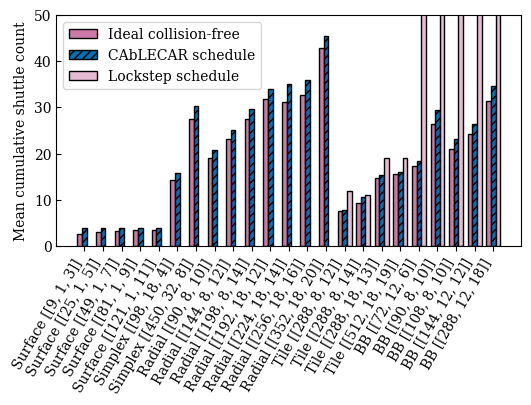

In [49]:
fig,ax = plt.subplots(figsize=(6,3))

ratios_ideal = []
ratios_lockstep_tile = []
ratios_lockstep_BB = []

x = 0
w = 0.25
made_tile_label = False
for i,(code,code_type,(n,k,d)) in enumerate(zip(codes,code_types, code_nkds)):
    ideal_mean = np.mean(ideal_distances[(code_type, (n,k,d))])
    ax.bar(x-w, ideal_mean, width=w, color='C1', edgecolor='k', label='Ideal collision-free' if i == 0 else None)

    sipp_mean = metrics[(code_type, (n,k,d))].avg_distance_traveled
    ax.bar(x, sipp_mean, width=w, color='C0', edgecolor='k', hatch='////', label='CAbLECAR schedule' if i == 0 else None)

    if code_type in ['Tile', 'BB']:
        tiled_mean = metrics_tiled[(code_type, (n,k,d))].avg_distance_traveled
        ax.bar(x+w, tiled_mean, width=w, color=plotter.interpolate('C1', 'w', 0.5), edgecolor='k', label='Lockstep schedule' if not made_tile_label else None)
        made_tile_label = True
        if code_type == 'Tile':
            ratios_lockstep_tile.append(sipp_mean / tiled_mean)
        else:
            ratios_lockstep_BB.append(sipp_mean / tiled_mean)
    # if code_type == 'Surface':
    #     tiled_mean = 4
    #     ax.bar(x+w/2, tiled_mean, width=w, color=plotter.interpolate('C1', 'w', 0.5), label='Lockstep schedule' if not made_tile_label else None)
    #     made_tile_label = True

    x += 1

    ratios_ideal.append(sipp_mean / ideal_mean)

    if code_type == 'BB':
        print(tiled_mean, sipp_mean)

ax.set_xticks(range(len(codes)), labels=[f'{code_type} [[{n}, {k}, {d}]]' for code_type,(n,k,d) in zip(code_types, code_nkds)], ha='right', rotation=60)
ax.set_ylabel('Mean cumulative shuttle count')
ax.legend()
ax.tick_params(axis='y', direction='in')

def geomean(nums):
    return np.pow(np.prod(nums), 1/len(nums))
print(f'{(geomean(ratios_ideal)-1)*100:0.2f}% increase over ideal')
print(f'{(1-geomean(ratios_lockstep_tile))*100:0.2f}% reduction from lockstep (Tile)')
print(f'{(1-geomean(ratios_lockstep_BB))*100:0.2f}% reduction from lockstep (BB)')

plt.ylim(top=50)

plt.savefig('notebooks/fig/14_greedy_vs_ideal.pdf', bbox_inches='tight')
plt.savefig('notebooks/fig/14_greedy_vs_ideal.svg', bbox_inches='tight')
plt.show()